# Q-DiffNet: learned diffusion with Sinkhorn-normalized kernels

The learning side of the paper replaces DiffusionNet's spectral heat diffusion
with `KernelDiffusionLayer`: the Sinkhorn-normalized Gaussian kernel applied
directly from point positions, with a **learned bandwidth per channel** —
no precomputed Laplacian or eigenbasis needed at training time.

Requires the `[torch]` extra (and optionally `pykeops` for the `keops` backend):

```bash
pip install -e ".[torch]"
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch as th

from sinkhornkernels import mesh as skmesh
from sinkhornkernels.torch.nn import DiffusionNet, KernelDiffusionLayer
from sinkhornkernels.torch.sinkhorn import sinkhorn_log, marginal_error

import plot_utils as plu

# pick the 3D rendering backend once: "pyvista" (interactive) or "matplotlib"
plu.set_backend("pyvista")

th.manual_seed(0)
rng = np.random.default_rng(0)

## Setup: a small point cloud

A batch of one armadillo point cloud with uniform masses:

In [ ]:
vertices, faces = skmesh.load_obj("../data/armadillo.obj")
vertices -= vertices.mean(axis=0)
vertices /= np.linalg.norm(vertices, axis=1).max()

N = 1500
points_np = skmesh.sample_surface(vertices, faces, N, rng=rng)
points = th.tensor(points_np, dtype=th.float32).unsqueeze(0)  # (1, N, 3)
masses = th.full((1, N), 1.0 / N)  # (1, N)
points.shape

torch.Size([1, 1500, 3])

## The three application backends agree

`KernelDiffusionLayer` can apply the normalized kernel with a dense torch
einsum, a PyKeOps lazy reduction (O(N) memory), or flash-compatible
scaled-dot-product **attention** — the Gaussian scores are plain dot products
of augmented embeddings, and at Sinkhorn convergence the row-softmax equals
the normalized operator exactly:

In [3]:
sigmas = th.tensor([0.05, 0.1, 0.2])
signals = th.randn(1, 3, N, 8)  # (B, p, N, C): one block of 8 features per scale

layer_dense = KernelDiffusionLayer(backend="dense", sinkhorn_n_iter=30)
layer_att = KernelDiffusionLayer(backend="attention", row_normalize=True, sinkhorn_n_iter=30)

out_dense = layer_dense(points, sigmas, signals, masses=masses)
out_att = layer_att(points, sigmas, signals, masses=masses)
print(f"attention vs dense: {(out_att - out_dense).abs().max():.2e}")

try:
    layer_keops = KernelDiffusionLayer(backend="keops", sinkhorn_n_iter=30)
    out_keops = layer_keops(points, sigmas, signals, masses=masses)
    print(f"keops     vs dense: {(out_keops - out_dense).abs().max():.2e}")
except ImportError:
    print("pykeops not installed - skipping the keops backend")

[KeOps] Warning : omp.h header is not in the path, disabling OpenMP. To fix this, you can set the environment
                  variable OMP_PATH to the location of the header before importing keopscore or pykeops,
                  e.g. using os.environ: import os; os.environ['OMP_PATH'] = '/path/to/omp/header'
[KeOps] Warning : Cuda libraries were not detected on the system or could not be loaded ; using cpu only mode
attention vs dense: 2.31e-05
keops     vs dense: 1.29e-05


## Effect of the bandwidth

Each channel of a Q-DiffNet layer owns its own $\sigma$; larger bandwidths mix
information over larger regions of the shape:

In [ ]:
dirac = th.zeros(1, 3, N, 1)
dirac[..., 0, 0] = N
out = layer_dense(points, sigmas, dirac, masses=masses)

panels = [
    plu.Points(
        points_np,
        out[0, i, :, 0].numpy(),
        size=3,
        title=rf"$Q_{{\sigma={sigmas[i]:.2f}}}\,\delta$",
    )
    for i in range(3)
]
plu.plot_panels(panels, cmap="inferno")

## Training a tiny Q-DiffNet

A miniature segmentation task: overfit a 2-block network (dense backend, no
gradient features) to predict a 4-part labeling of the cloud. The Sinkhorn
loop runs under `no_grad` — gradients reach the learned bandwidths through the
kernel application, as in the paper:

In [ ]:
from sklearn.cluster import KMeans

labels = th.tensor(KMeans(4, random_state=0, n_init=4).fit_predict(points_np), dtype=th.long)

net = DiffusionNet(
    in_dim=3,
    out_dim=4,
    n_features=8,
    n_feats_per_scale=2,
    N_block=2,
    diffusion_layer=lambda: KernelDiffusionLayer(backend="dense", sinkhorn_n_iter=5, n_apply=2),
    with_gradient_features=False,
    dropout=False,
)

opt = th.optim.Adam(net.parameters(), lr=5e-3)
losses = []
for step in range(150):
    opt.zero_grad()
    logits = net(points[0], masses[0], points=points[0])
    loss = th.nn.functional.cross_entropy(logits, labels)
    loss.backward()
    opt.step()
    losses.append(loss.item())

acc = (logits.argmax(-1) == labels).float().mean()
print(f"final loss {losses[-1]:.3f}, training accuracy {acc:.1%}")

final loss 0.022, training accuracy 99.6%


In [ ]:
# the 2D loss curve stays matplotlib; the two label clouds follow the chosen backend
plt.figure(figsize=(4, 3.6))
plt.plot(losses)
plt.xlabel("step")
plt.ylabel("cross-entropy")
plt.grid(alpha=0.3)
plt.title("training loss")
plt.tight_layout()

panels = [
    plu.Points(points_np, labels.numpy(), size=3, title="target parts"),
    plu.Points(points_np, logits.argmax(-1).numpy(), size=3, title="prediction"),
]
plu.plot_panels(panels, cmap="tab10", clim=[0, 9])

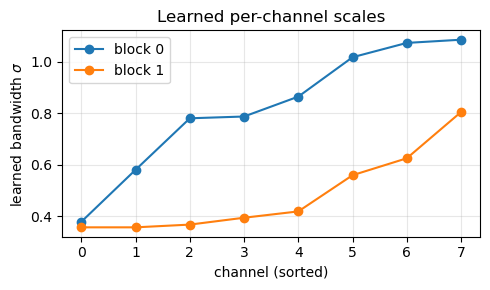

In [ ]:
sig = net.get_times().numpy()
plt.figure(figsize=(5, 3))
for b in range(sig.shape[0]):
    plt.plot(np.sort(sig[b]), "o-", label=f"block {b}")
plt.xlabel("channel (sorted)")
plt.ylabel(r"learned bandwidth $\sigma$")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Learned per-channel scales")
plt.tight_layout()

## Paper configuration

For the shape-correspondence experiments, Q-DiffNet uses `n_features=32`
channels with `n_feats_per_scale=8` features each, `n_apply=2` applications,
10 Sinkhorn iterations per forward pass, and the `keops` backend on GPU —
plugged into the ULRSSM training setup with mesh-derived WKS descriptors as
inputs. See the paper for details.